<a href="https://colab.research.google.com/github/nehaj2026/undergrad_ml_assignments/blob/main/NJ_04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?



1.   **What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?**
Adding the penalty to mean squared error helps prevent overfitting since it penalizes large parameter values, which ensures the model is not relying too heavily on any one feature. This ensures the model is not memorizing noise in training data, and allows it to instead focus on generalizable patterns for its predictions.

2.   **How does regularization provide a way of exploring the bias-variance trade-off?**
Regularization adds a penalty term to the loss function for large coefficients, which forces the model to be simpler. By doing so, regularization reduces variance in the model by preventing it from learning the noise in the training data. If the penalty is too high, the model will be too simple which increases bias and causes underfitting (low variance). If the penalty is too low, then the bias is low but there is high variance (overfitting) Thus, the bias-variance trade-off is observed with what the penalty is for regularization. If the penalty is high, it minimizes variance. If the penalty is low, it minimizes bias.

3. **What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?**
LASSO regression shrinks coefficients to zero, which allows it to performs feature selection on attributes and eliminate certain attributes. Ridge regression reduces coefficients to nearly zero but does not actually eliminate them. The differences between each of the regressions results in LASSO having a simpler model with less attributes used for prediction and Ridge results in a more balanced/stable model where all of the original attributes are still used for prediction. You would use LASSO for high-dimensional data where only a few of the attributes are significant and you would use Ridge when most/all of the attributes are important for prediction.

4. **How do we typically scale variables for use in regularized regression? Why?**
Variables are scaled using standardization by subtracting the mean and dividing by the standard deviation, where each variable will have a mean of zero and a standard deviation of 1. This allows for attributes to be on even scaling for the penalty to be applied and makes sure that larger attributes are not unfairly penalized since that could cause bias.

5. **How is the penalty  𝛼  typically selected?**
Alpha is selected through K-fold cross validation by training the model on numerous values of alpha and selecting the alpha that provides the lowest average mean squared error across all of the K folds.

6. **When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?**
The penalty term is not included when evaluating the cross-validated MSE because when evaluating the test set (as in, the part of data held out), the model is supposed to be predicting the outcome for new observations to test how well the model performs on new data. Thus, the penalty term is not included since in the real word (when you deploy the model) you will not be able to apply penalties to coefficients. The penalty term is only used for the training set to shrink coefficients and is not used as a measure of prediction error.

In [2]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [3]:
#Question 2.1: Import cars dataset
import pandas as pd
import numpy as np
df = pd.read_csv('/content/data/cars_hw.csv')
df

#Create age variable for each vehicle
df['Age'] = np.max(df['Make_Year']) - df['Make_Year']
#I used the most recent year from the dataset to establish as the current year rather than 2026 - I thought this would make the analysis more reflective of the period the data was collected

#A) Take milage run and age and use Polynomial Features to create a third degree expansion
X = df[['Mileage_Run', 'Age']]
y = df['Price']

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 3, interaction_only = False, include_bias = False)
X_poly = poly.fit_transform(X)
X_poly

#B) Use StandardScaler to z-score normalize them
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [4]:
#Question #2.2: Use your features, run linear regression. What is the sign for the interaction between Mileage_Run and Age?
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)


featurename = poly.get_feature_names_out(['Mileage_Run', 'Age'])
featurecoef = pd.DataFrame({'feature': featurename, 'coefficient': lin_reg.coef_})
print(featurecoef)

interaction = featurecoef[featurecoef['feature'] == 'Mileage_Run Age']
print(np.sign(interaction['coefficient'].values[0]))
# The interaction sign is negative, which means the effect of mileage on price gets more negative as the car is older

             feature    coefficient
0        Mileage_Run  458071.119627
1                Age -136698.072100
2      Mileage_Run^2  -91643.120024
3    Mileage_Run Age -898405.751356
4              Age^2  113603.822348
5      Mileage_Run^3  -65144.896599
6  Mileage_Run^2 Age  229021.676556
7  Mileage_Run Age^2  368955.713359
8              Age^3  -84038.066146
-1.0


In [5]:
#Question #2.3: Use LassoCV to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid alphas = np.logspace(1,3,20) to find the cost parameter)
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas = alphas, cv = 20, max_iter = 100000)
lasso_cv.fit(X_scaled, y)
print(lasso_cv.alpha_)

#The best alpha is 784.76

784.7599703514607


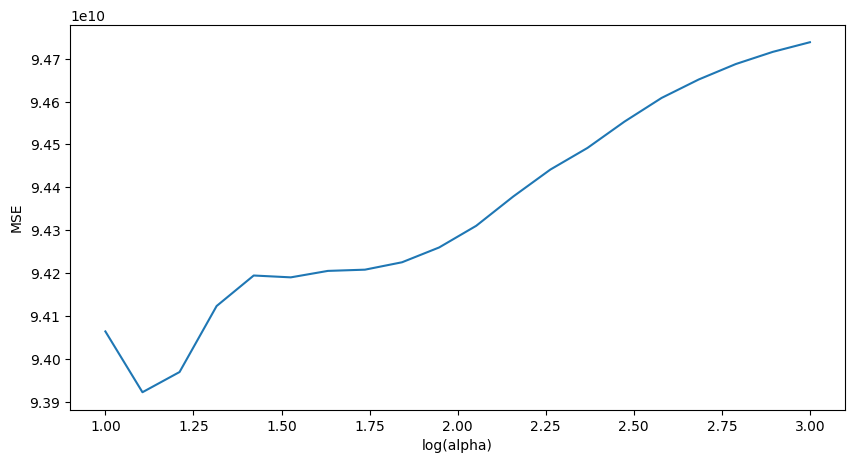

In [6]:
#Question #2.4: Plot the cross-validated MSE by  𝛼 .
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 5))
plt.plot(np.log10(alphas), lasso_cv.mse_path_.mean(axis = 1))
plt.xlabel('log(alpha)')
plt.ylabel('MSE')
plt.show()


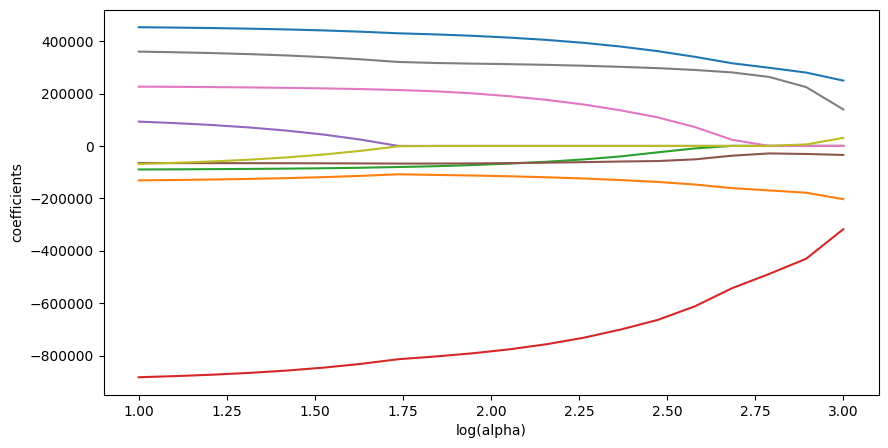

In [7]:
#Question #2.5: Plot the coefficient paths by  𝛼 .
from sklearn.linear_model import Lasso

coefs = []
for a in alphas:
  lasso = Lasso(alpha = a, max_iter = 100000)
  lasso.fit(X_scaled, y)
  coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize = (10, 5))
plt.plot(np.log10(alphas), coefs)
plt.xlabel('log(alpha)')
plt.ylabel('coefficients')
plt.show()

In [8]:
#Question #2.6: Which features are actually selected? What proportion are set equal to zero?
lasso = Lasso(alpha = lasso_cv.alpha_, max_iter = 100000)
lasso.fit(X_scaled, y)

coefs_lasso = pd.DataFrame({'feature': featurename, 'coefficient': lasso.coef_})
print(coefs_lasso)

#Features actually selected:
print(coefs_lasso[coefs_lasso['coefficient'] != 0])
#Features actually selected and their coefficient values are below

#Proportion set equal to zero:
print(len(coefs_lasso[coefs_lasso['coefficient'] == 0]) / len(coefs_lasso))
#0.33 of features were set equal to zero

             feature    coefficient
0        Mileage_Run  279901.144475
1                Age -178627.649418
2      Mileage_Run^2      -0.000000
3    Mileage_Run Age -430522.371167
4              Age^2      -0.000000
5      Mileage_Run^3  -30772.352392
6  Mileage_Run^2 Age       0.000000
7  Mileage_Run Age^2  224381.027339
8              Age^3    5666.626835
             feature    coefficient
0        Mileage_Run  279901.144475
1                Age -178627.649418
3    Mileage_Run Age -430522.371167
5      Mileage_Run^3  -30772.352392
7  Mileage_Run Age^2  224381.027339
8              Age^3    5666.626835
0.3333333333333333


In [9]:
#Question 2.7: Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?
reg_v_lasso = pd.DataFrame({'feature': featurename, 'linear regression': lin_reg.coef_, 'lasso': coefs_lasso['coefficient'].values})

#Lasso coefficients are smaller in magnitude, which makes sense because of the penalty
#This could indicate the linear regression model may have been overfitting because of relying heavily on certain large coefficients

#Magnitude changes
reg_v_lasso['magnitude increase'] = reg_v_lasso['lasso'].abs() > reg_v_lasso['linear regression'].abs()
print('coefficients increasing in magnitude')
print(reg_v_lasso[reg_v_lasso['magnitude increase']])
#Age increased in magnitude

#Sign changes
reg_v_lasso['sign change'] = (np.sign(reg_v_lasso['linear regression']) != np.sign(reg_v_lasso['lasso'])) & (reg_v_lasso['lasso'] != 0)
print('coefficients changing sign')
print(reg_v_lasso[reg_v_lasso['sign change']])
#Age^3 changed in sign


coefficients increasing in magnitude
  feature  linear regression          lasso  magnitude increase
1     Age       -136698.0721 -178627.649418                True
coefficients changing sign
  feature  linear regression        lasso  magnitude increase  sign change
8   Age^3      -84038.066146  5666.626835               False         True


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [13]:
#Question #3.1: Use PolynomialFeatures to create a third-degree expansion of age, ejection_fraction, and serum_creatinine, and then use StandardScaler to  𝑧 -score normalize your results. Use PolynomialFeatures with interaction_only=True to interact the dummy/categorical variables anaemia, diabetes, high_blood_pressure, and smoking. Concatenate these results into your feature/covariate matrix.
df = pd.read_csv('/content/data/heart_failure_clinical_records_dataset.csv')

poly = PolynomialFeatures(degree = 3, interaction_only = False, include_bias = False)
X_scaled = scaler.fit_transform(poly.fit_transform(df[['age', 'ejection_fraction', 'serum_creatinine']]))

poly2 = PolynomialFeatures(degree = 3, interaction_only = True, include_bias = False)
X_poly2 = poly2.fit_transform(df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']])

X = np.concatenate((X_scaled, X_poly2), axis = 1)
y = df['DEATH_EVENT']

In [14]:
#Question #3.2: Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
lin_reg = LinearRegression()
lin_reg.fit(X, y)

featurenames = np.concatenate([poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine']), poly2.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])])
featurecoef = pd.DataFrame({'feature': featurenames, 'coefficient': lin_reg.coef_})
print(featurecoef)

#Smoking and high blood pressue both have negative signs, indicating that there is a negative association of these attributes with death.
#This is counterintuitive since, I would imagine these are strong factors in predicting death and would expect a positive association.

#Higher order poewrs may help explain this since the interaction term for smoking and high blood pressure is positive, meaning that these features together do have a positive association with death.
#There were initially negative assocations due to those features being considered solely with their association with death, but with the interactions, the relationship is more intuitive.


                                   feature  coefficient
0                                      age     1.549928
1                        ejection_fraction    -2.025371
2                         serum_creatinine    -0.739027
3                                    age^2    -3.547991
4                    age ejection_fraction    -0.861860
5                     age serum_creatinine     1.680570
6                      ejection_fraction^2     3.317931
7       ejection_fraction serum_creatinine     2.604767
8                       serum_creatinine^2    -2.703084
9                                    age^3     1.889040
10                 age^2 ejection_fraction     1.022027
11                  age^2 serum_creatinine    -0.672141
12                 age ejection_fraction^2     0.017577
13  age ejection_fraction serum_creatinine    -1.584620
14                  age serum_creatinine^2     1.433246
15                     ejection_fraction^3    -1.253594
16    ejection_fraction^2 serum_creatinine    -1

In [15]:
#Question 3.3: Use LassoCV to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid alphas = np.logspace(-5,5,30) to find the cost parameter)
alphas = np.logspace(-5, 5, 30)
lasso_cv = LassoCV(alphas = alphas, cv = 20, max_iter = 100000)
lasso_cv.fit(X, y)
print(lasso_cv.alpha_)

#The best alpha is 0.0057

0.005736152510448681


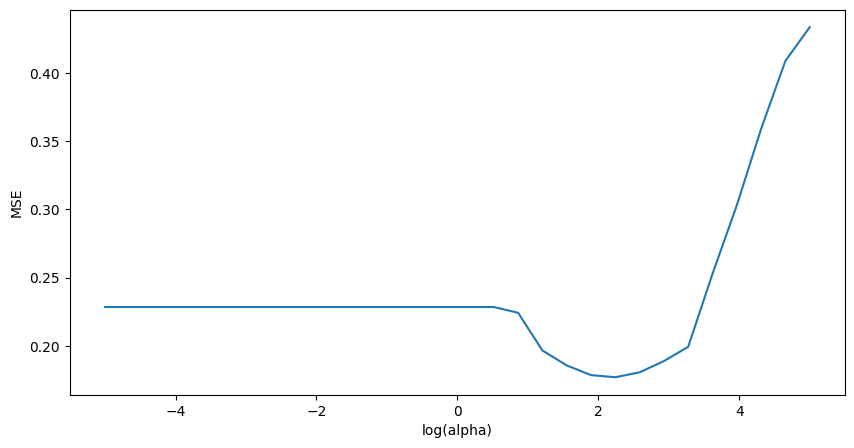

In [16]:
#Question 3.4: Plot the cross-validated MSE by  𝛼 .
plt.figure(figsize = (10, 5))
plt.plot(np.log10(alphas), lasso_cv.mse_path_.mean(axis = 1))
plt.xlabel('log(alpha)')
plt.ylabel('MSE')
plt.show()

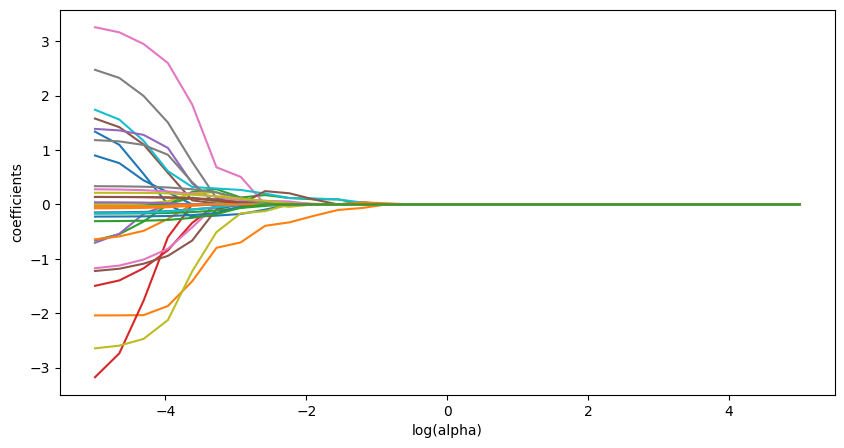

In [17]:
#Question 3.5: Plot the coefficient paths by  𝛼 .
coefs = []
for a in alphas:
  lasso = Lasso(alpha = a, max_iter = 100000)
  lasso.fit(X, y)
  coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize = (10, 5))
plt.plot(np.log10(alphas), coefs)
plt.xlabel('log(alpha)')
plt.ylabel('coefficients')
plt.show()

In [18]:
#Question 3.6: Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.
lasso = Lasso(alpha = lasso_cv.alpha_, max_iter = 100000)
lasso.fit(X, y)

coefs_lasso = pd.DataFrame({'feature': featurenames, 'coefficient': lasso.coef_})

print('Selected features:')
print(coefs_lasso[coefs_lasso['coefficient'] != 0])
#12 features were selected as seen in the output below

print('Coefs set equal to zero:')
print(len(coefs_lasso[coefs_lasso['coefficient'] == 0]) / len(coefs_lasso))
#The proportion of coefficients set equal to zero was 0.636

reg_v_lasso = pd.DataFrame({'feature': featurenames, 'linear regression': lin_reg.coef_, 'lasso': coefs_lasso['coefficient'].values})

reg_v_lasso['magnitude increase'] = reg_v_lasso['lasso'].abs() > reg_v_lasso['linear regression'].abs()
print('coefficients increasing in magnitude')
print(reg_v_lasso[reg_v_lasso['magnitude increase']])
#serum_creatinine^3 increased in magnitude

#Overall, Lasso coefficients are much smaller that linear regression ones
#Lasso regularization made the model simpler and reduced the features to be 12 features

reg_v_lasso['sign change'] = ((np.sign(reg_v_lasso['linear regression']) != np.sign(reg_v_lasso['lasso'])) & (reg_v_lasso['lasso'] != 0))
print('coefficients changing sign')
print(reg_v_lasso[reg_v_lasso['sign change']])
#Yes, 6 features changed sign including serum_creatinine, ejection_fraction^3, ejection_fraction^2 serum_creatinine, anaemia, diabetes,and high_blood_pressure

#The sign patterns for the lasso make more sense. As I mentioned earlier, it is not inuitive for high blood pressure to have a negative association with death. Same thing for serum creatinine. Thus, lasso having the signs changed to positive makes more intuitive sense
#In terms of the bias variance tradeoff, the linear regression has low bias and high variance due to having relatively few observations and many features, there is multicolinearity and overfitting.
#Lasso adds bias by making some cofficients zero, but that reduces variance and makes the model easier to interpret.

Selected features:
                                 feature  coefficient
1                      ejection_fraction    -0.329656
2                       serum_creatinine     0.116875
9                                  age^3     0.117992
15                   ejection_fraction^3     0.204822
16  ejection_fraction^2 serum_creatinine     0.032801
18                    serum_creatinine^3    -0.043266
19                               anaemia     0.014178
20                              diabetes     0.000607
21                   high_blood_pressure     0.013608
26          diabetes high_blood_pressure     0.053968
27                      diabetes smoking     0.003466
28           high_blood_pressure smoking     0.017805
Coefs set equal to zero:
0.6363636363636364
coefficients increasing in magnitude
               feature  linear regression     lasso  magnitude increase
18  serum_creatinine^3          -0.014908 -0.043266                True
coefficients changing sign
                           

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

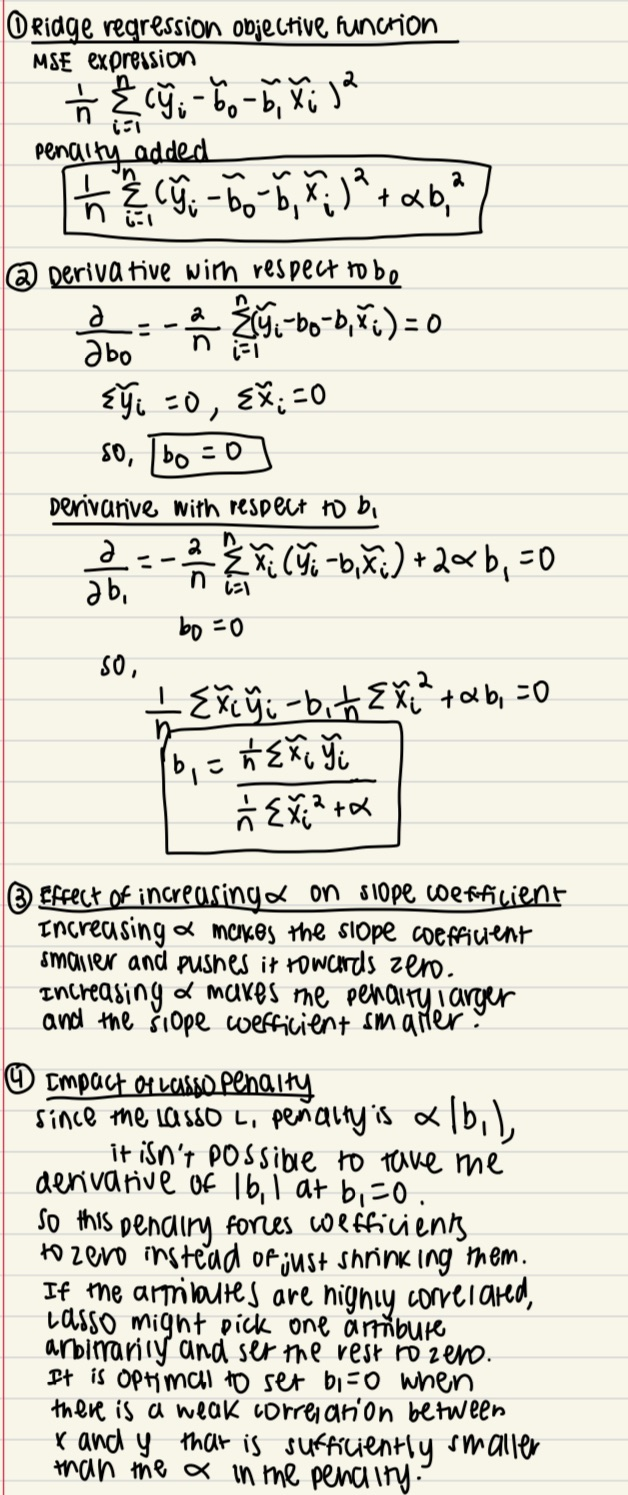